In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib as mpl
from functions import compute_costs

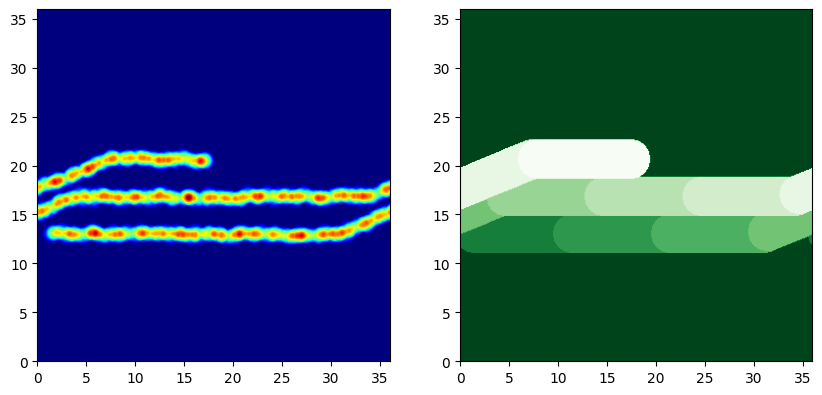

In [2]:
elevation_map = np.load('fig03/elevation_map.npy')
offsets = np.load('fig03/offsets.npy')
trampled = np.load('fig03/erosion_layer.npy')
depletion_layer = np.load('fig03/resource_layer.npy')
agent_pos = np.load('fig03/agent_pos.npy')

# other undefined parameters: 
resolution = 10
step_size = resolution//2
w1 = 8.25
w2 = 4.75
scale = 36
size = scale*resolution

total_erosion = elevation_map - trampled 

fig, axs = plt.subplots(ncols=2, figsize=(10,20))

axs[0].imshow(total_erosion - np.min(total_erosion), origin='lower', cmap='jet', extent=(0, scale, 0, scale))
#plt.colorbar(label='Erosion')
axs[0].grid(False)


axs[1].imshow(depletion_layer, origin='lower', cmap='Greens', extent=(0, scale, 0, scale))
#plt.colorbar(label='Depletion Layer')
axs[1].grid(False)

plt.show()

# Compute costs and meshgrid
angles_mesh, radial_mesh, gradient_cost, depletion_cost = compute_costs(agent_pos[:,0], 36, step_size, 20*step_size, trampled, depletion_layer, np.shape(total_erosion)[0], offsets, resolution, cumulative=True) #compute_cumulative_costs(agent_pos[:,0], trampled, depletion_layer, size, offsets)

# Convert polar coordinates to Cartesian for scatter plot
x_mesh = agent_pos[0,0] + radial_mesh * np.cos(angles_mesh)
y_mesh = agent_pos[1,0] + radial_mesh * np.sin(angles_mesh)

Visualize decision horizon and local energy landscape components

/tmp/ipykernel_101652/1551289091.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')


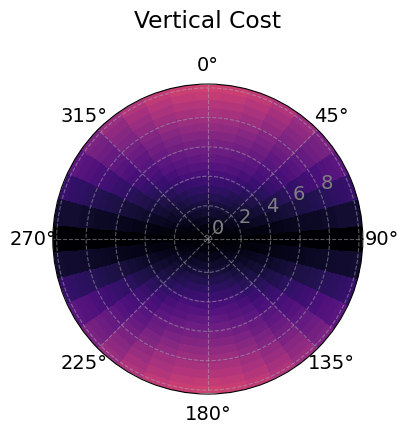

/tmp/ipykernel_101652/1551289091.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')


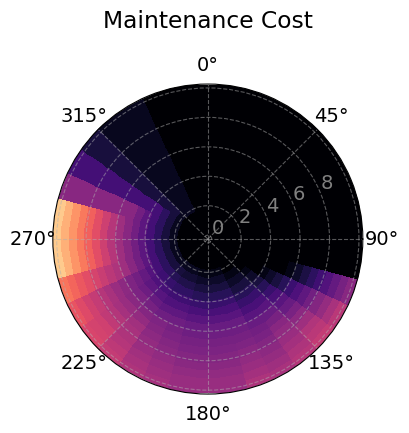

/tmp/ipykernel_101652/1551289091.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')


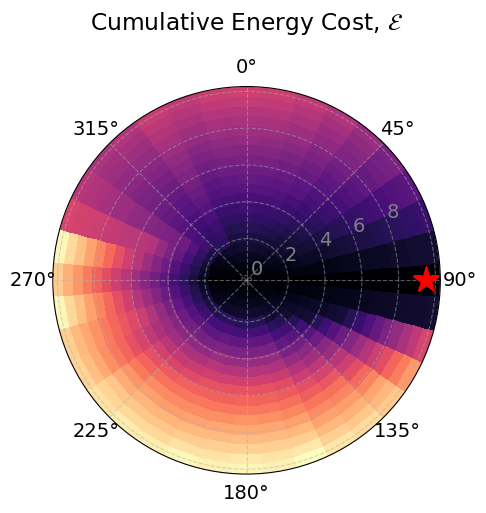

/tmp/ipykernel_101652/1551289091.py:49: UserWarning: Adding colorbar to a different Figure <Figure size 500x600 with 1 Axes> than <Figure size 25x500 with 1 Axes> which fig.colorbar is called on.
  cbar = fig4.colorbar(pc3, cax=ax4, orientation='vertical')


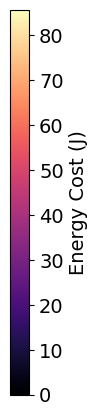

/tmp/ipykernel_101652/1551289091.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 500x600 with 1 Axes> than <Figure size 500x35 with 1 Axes> which fig.colorbar is called on.
  cbar = fig5.colorbar(pc3, cax=ax5, orientation='horizontal')


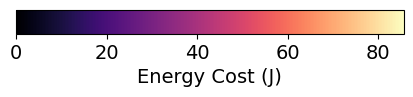

/tmp/ipykernel_101652/1551289091.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='k')


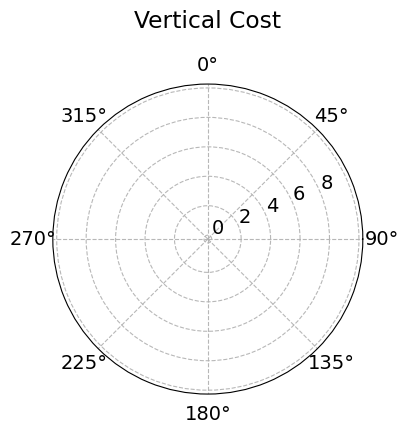

In [3]:
# Compute the total cost for normalization
total_cost = (w1 * gradient_cost) + (w2 * depletion_cost)
vmin, vmax = total_cost.min(), total_cost.max()

# Edit angular labels
custom_labels = ['90°', '45°', '0°', '315°', '270°', '225°', '180°', '135°']

# Create a shared normalization for all plots
norm = plt.Normalize(vmin, vmax)

plt.rcParams.update({'font.size': 14})

colormap = 'magma'

# Plot Gradient Cost
fig1, ax1 = plt.subplots(figsize=(4, 5), subplot_kw={'projection': 'polar'})
pc1 = ax1.pcolormesh(angles_mesh, radial_mesh, w1 * gradient_cost, shading='auto', cmap=colormap, norm=norm)
ax1.set_title(r"Vertical Cost", pad=20)
ax1.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')
ax1.set_xticks(np.linspace(0, 2 * np.pi, len(custom_labels), endpoint=False))
ax1.set_xticklabels(custom_labels)
ax1.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Plot Depletion Cost
fig2, ax2 = plt.subplots(figsize=(4, 5), subplot_kw={'projection': 'polar'})
pc2 = ax2.pcolormesh(angles_mesh, radial_mesh, w2 * depletion_cost, shading='auto', cmap=colormap, norm=norm)
ax2.set_title(r"Maintenance Cost", pad=20)
ax2.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')
ax2.set_xticks(np.linspace(0, 2 * np.pi, len(custom_labels), endpoint=False))
ax2.set_xticklabels(custom_labels)
ax2.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Plot Total Cost
fig3, ax3 = plt.subplots(figsize=(5, 6), subplot_kw={'projection': 'polar'})
pc3 = ax3.pcolormesh(angles_mesh, radial_mesh, total_cost, shading='auto', cmap=colormap, norm=norm)
ax3.set_title(r"Cumulative Energy Cost, $\mathcal{E}$", pad=20)
ax3.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='grey')
ax3.grid(True, linestyle='--', alpha=0.5)

ax3.set_xticks(np.linspace(0, 2 * np.pi, len(custom_labels), endpoint=False))
ax3.set_xticklabels(custom_labels)
ax3.plot(0, 95, "*", markersize=20, color="r")
plt.show()

# Plot Colorbar as a Separate Figure
fig4, ax4 = plt.subplots(figsize=(0.25, 5))
cbar = fig4.colorbar(pc3, cax=ax4, orientation='vertical')
cbar.set_label("Energy Cost (J)")
plt.show()

# Plot Colorbar as a Separate Figure
fig5, ax5 = plt.subplots(figsize=(5, 0.35))
cbar = fig5.colorbar(pc3, cax=ax5, orientation='horizontal')
cbar.set_label("Energy Cost (J)")
plt.subplots_adjust(bottom=0.2)  # Adjust bottom padding as needed
plt.show()

fig6, ax6 = plt.subplots(figsize=(4, 5), subplot_kw={'projection': 'polar'})

white_cmap = mpl.colors.ListedColormap(['white'])

pc1 = ax6.pcolormesh(
    angles_mesh,
    radial_mesh,
    w1 * gradient_cost,
    shading='auto',
    cmap=white_cmap,     # all faces become white
    edgecolors='none'    # remove mesh lines (optional)
)

ax6.set_title(r"Vertical Cost", pad=20)
ax6.set_yticklabels([f'{int(tick)}' for tick in np.arange(0, 10, 2)], color='k')
ax6.set_xticks(np.linspace(0, 2 * np.pi, len(custom_labels), endpoint=False))
ax6.set_xticklabels(custom_labels)
ax6.grid(True, linestyle='--', alpha=0.9)

plt.show()

Create bar plots to match

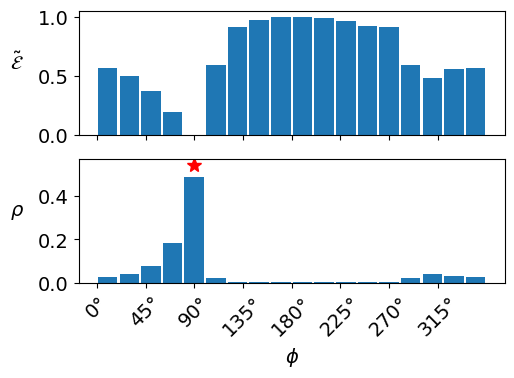

In [4]:
adjusted_angles_mesh = ((angles_mesh - np.pi) % (2 * np.pi)) - np.pi  # Wrap to [-π, π]
adjusted_angles_mesh = -adjusted_angles_mesh  # Flip horizontally
adjusted_angles_mesh = (adjusted_angles_mesh + np.pi / 2) % (2 * np.pi)  # Rotate by 90°

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(5.5,4), sharex=True)

major_angles = np.rad2deg(adjusted_angles_mesh[radial_mesh == 100])[::2]

major_costs = total_cost[radial_mesh == 100][::2]

normal_costs = major_costs/np.max(major_costs)
normal_costs = np.nan_to_num(normal_costs, nan=0.0) # if np.max(total_costs) happens to be zero
exp_costs = np.exp(-5 * normal_costs)

ax1.bar(major_angles, normal_costs, width=18)
ax1.set_ylabel(r'$\tilde{\mathcal{E}}$', rotation=0, labelpad=15)

# probability of direction choice is based on exponential cost
prob = exp_costs / np.sum(exp_costs)
ax2.bar(major_angles, prob, width=18)
#ax2.set_yscale('log')
ax2.set_ylabel(r'$\rho$', rotation=0, labelpad=15)
ax2.set_xlabel(r'$\phi$')

ax2.plot(90, 0.54, "*", markersize=10, color="r")

custom_labels = ['0°', '45°', '90°', '135°',  '180°', '225°', '270°', '315°']
ax2.set_xticks(np.linspace(0, 360, len(custom_labels), endpoint=False))
ax2.set_xticklabels(custom_labels, rotation=45)
plt.subplots_adjust(bottom=0.2)  # Adjust bottom padding as needed
# plt.savefig('Figures/SPBarplot.png', transparent=True, bbox_inches='tight')
plt.show()

Plot 3D resource layer

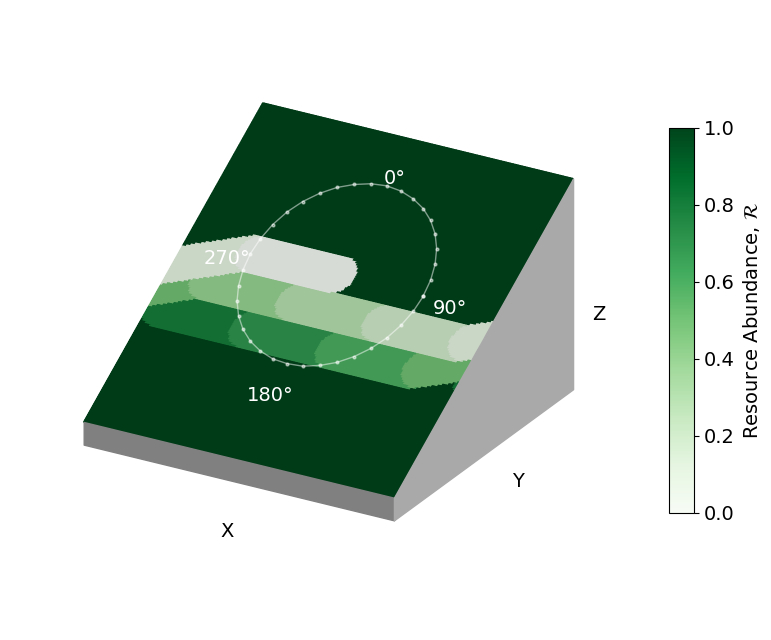

In [5]:
plt.rcParams.update({'font.size': 14})

# Create the 3D surface plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

# Circle parameters
r = 100  # Radius of the circle
n_points = 37  # Number of points for the circle

# Generate circle points
angles = np.linspace(0, 2 * np.pi, n_points)
circle_x = (r * np.cos(angles)) + agent_pos[0]
circle_y = (r * np.sin(angles)) + agent_pos[1]

# Clip points to ensure they are within terrain bounds
circle_x = np.clip(circle_x, 0, size - 1)
circle_y = np.clip(circle_y, 0, size - 1)

# Sample z-values from the elevation map
circle_z = elevation_map[circle_y.astype(int), circle_x.astype(int)] + 1 # Offset by 1 to plot above the surface

# Plot the circle
ax.plot(circle_x, circle_y, circle_z, color='w', ls= '-', marker='o', markersize=2, lw=1, zorder=4, alpha=0.5)


# Create a grid for the surface plot
x = np.arange(trampled.shape[0])
y = np.arange(trampled.shape[1])
x, y = np.meshgrid(x, y)

# Calculate the difference
difference = depletion_layer

# Normalize the difference for coloring
norm = plt.Normalize(difference.min(), difference.max())
colors = plt.cm.Greens(norm(difference))

# Plot the surface
ax.plot_surface(x, y, elevation_map, facecolors=colors, cstride=2, rstride=2)

# Set the base level for the volume
z_min = trampled.min() - 25  # Adjust to control the depth

# Define and add the side "walls" using Poly3DCollection
verts_bottom = [
    # Bottom edge wall
    [(x[0, i], y[0, i], trampled[0, i]) for i in range(x.shape[1])] +
    [(x[0, i], y[0, i], z_min) for i in range(x.shape[1])][::-1],
]

verts_right = [
    # Right edge wall
    [(x[i, -1], y[i, -1], trampled[i, -1]) for i in range(x.shape[0])] +
    [(x[i, -1], y[i, -1], z_min) for i in range(x.shape[0])][::-1]
]

# Add walls as polygons with Poly3DCollection
poly_bottom = Poly3DCollection(verts_bottom, color='gray', alpha=1)
ax.add_collection3d(poly_bottom)
poly_right = Poly3DCollection(verts_right, color='darkgray', alpha=1)
ax.add_collection3d(poly_right)

# Remove axes lines and ticks
ax.axis('off')

# Manually add axis labels as text elements
ax.text2D(0.35, 0.15, "X", transform=ax.transAxes, ha='center', fontsize=14)
ax.text2D(0.82, 0.23, "Y", transform=ax.transAxes, ha='center', fontsize=14)
ax.text2D(0.96, 0.5, "Z", transform=ax.transAxes, ha='right', fontsize=14)

# Manually add axis labels as text elements
ax.text2D(0.62, 0.72, '0°', transform=ax.transAxes, ha='center', fontsize=14, c='w')
ax.text2D(0.71, 0.51, '90°', transform=ax.transAxes, ha='center', fontsize=14, c='w')
ax.text2D(0.42, 0.37, '180°', transform=ax.transAxes, ha='center', fontsize=14, c='w')
ax.text2D(0.35, 0.59, '270°', transform=ax.transAxes, ha='center', fontsize=14, c='w')

ax.view_init(elev=25)#, elev=0)

ax.set_aspect('equal')

# Create a ScalarMappable and add a colorbar
mappable = mpl.cm.ScalarMappable(norm=norm, cmap='Greens')
mappable.set_array(difference)

# Add the colorbar to the figure
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=15)
cbar.set_label(r'Resource Abundance, $\mathcal{R}$')

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# plt.savefig('Figures/Resourcelayer.png', transparent=True)
plt.show()

Plot 3D terrain layer

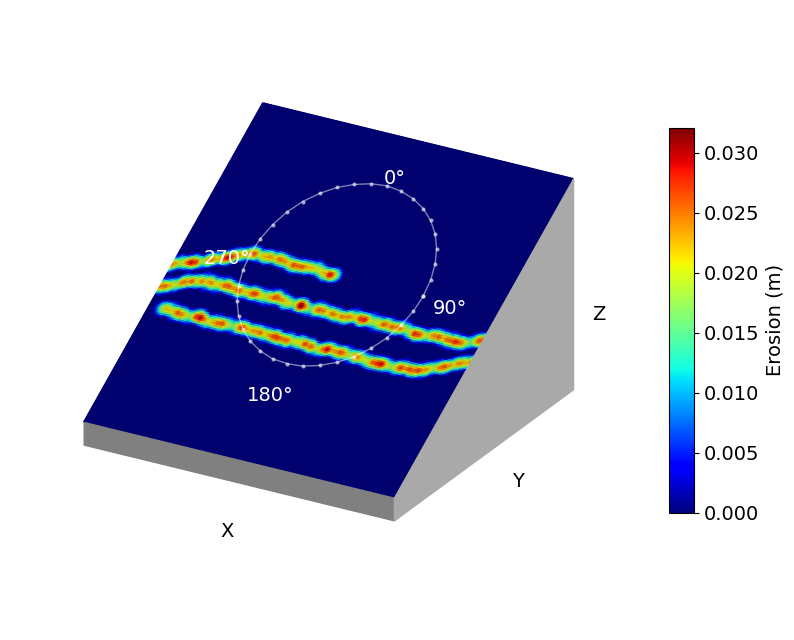

In [6]:
total_erosion = trampled - elevation_map

# Create the 3D surface plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

# Circle parameters
r = 100  # Radius of the circle
n_points = 37 # Number of points for the circle

# Generate circle points
angles = np.linspace(0, 2 * np.pi, n_points)
circle_x = (r * np.cos(angles)) + agent_pos[0]
circle_y = (r * np.sin(angles)) + agent_pos[1]

# Clip points to ensure they are within terrain bounds
circle_x = np.clip(circle_x, 0, size - 1)
circle_y = np.clip(circle_y, 0, size - 1)

# Sample z-values from the elevation map
circle_z = elevation_map[circle_y.astype(int), circle_x.astype(int)] + 1 # Offset by 1 to plot above the surface

# Manually add axis labels as text elements
ax.text2D(0.62, 0.72, '0°', transform=ax.transAxes, ha='center', fontsize=14, c='w', zorder=3)
ax.text2D(0.71, 0.51, '90°', transform=ax.transAxes, ha='center', fontsize=14, c='w', zorder=3)
ax.text2D(0.42, 0.37, '180°', transform=ax.transAxes, ha='center', fontsize=14, c='w', zorder=3)
ax.text2D(0.35, 0.59, '270°', transform=ax.transAxes, ha='center', fontsize=14, c='w', zorder=3)

# Plot the circle
ax.plot(circle_x, circle_y, circle_z, color='w', ls= '-', marker='o', markersize=2, lw=1, zorder=4, alpha=0.5)

# Create a grid for the surface plot
x = np.arange(trampled.shape[0])
y = np.arange(trampled.shape[1])
x, y = np.meshgrid(x, y)

# Calculate the difference
difference = elevation_map - trampled

# Normalize the difference for coloring
norm = plt.Normalize(difference.min(), difference.max())
colors = plt.cm.jet(norm(difference))

# Plot the surface
ax.plot_surface(x, y, trampled, facecolors=colors, cstride=2, rstride=2)

# Set the base level for the volume
z_min = trampled.min() - 25  # Adjust to control the depth

# Define and add the side "walls" using Poly3DCollection
verts_bottom = [
    # Bottom edge wall
    [(x[0, i], y[0, i], trampled[0, i]) for i in range(x.shape[1])] +
    [(x[0, i], y[0, i], z_min) for i in range(x.shape[1])][::-1],
]

verts_right = [
    # Right edge wall
    [(x[i, -1], y[i, -1], trampled[i, -1]) for i in range(x.shape[0])] +
    [(x[i, -1], y[i, -1], z_min) for i in range(x.shape[0])][::-1]
]

# Add walls as polygons with Poly3DCollection
poly_bottom = Poly3DCollection(verts_bottom, color='gray', alpha=1, zorder=0)
ax.add_collection3d(poly_bottom)
poly_right = Poly3DCollection(verts_right, color='darkgray', alpha=1, zorder=0)
ax.add_collection3d(poly_right)

# Remove axes lines and ticks
ax.axis('off')

# Manually add axis labels as text elements
ax.text2D(0.35, 0.15, "X", transform=ax.transAxes, ha='center', fontsize=14)
ax.text2D(0.82, 0.23, "Y", transform=ax.transAxes, ha='center', fontsize=14)
ax.text2D(0.96, 0.5, "Z", transform=ax.transAxes, ha='right', fontsize=14)

ax.view_init(elev=25)#, elev=0)

ax.set_aspect('equal')

# Create a ScalarMappable and add a colorbar
mappable = mpl.cm.ScalarMappable(norm=norm, cmap='jet')
mappable.set_array(difference)

# Add the colorbar to the figure
labels = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=15, ticks=labels, format='%.3f')

# Set custom tick labels
cbar.ax.set_yticklabels(["0.000", "0.005", "0.010", "0.015", "0.020", "0.025", "0.030"])
cbar.set_label('Erosion (m)')

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.savefig('Figures/Erosionlayer.png', transparent=True)

plt.show()